**Launch this notebook:**

colab todo<!-- [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NERC-CEH/access-UK-radar-data/blob/main/notebooks/CEH-GEAR-1hr/gear_netcdf_python.ipynb) -->
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/Thomasjkeel/access-UK-radar-data/HEAD)

(CTRL + Click to open in a new tab)

Full instructions available in the [accompanying README](https://github.com/NERC-CEH/access-UK-radar-data/blob/main/README.md#How-to-run-these-notebooks).

---

**Setup**
If you would like to install required packages, uncomment and run cell below...

In [ ]:
# %%capture
# !pip install xarray[io] cartopy boto3 geopandas numpy pyproj s3fs rasterio matplotlib

In [1]:
import datetime
import itertools
from pathlib import Path

import boto3
import geopandas as gpd
import numpy as np
import pyproj
import s3fs
import xarray as xr

import cartopy.crs as ccrs
import matplotlib.pyplot as plt

from botocore import UNSIGNED
from botocore.config import Config

# Set up aws reader

In [2]:
bucket_name = "met-office-radar-obs-data"
prefix = "radar/2024/12/"
search_term = "radar_rainrate_composite"

# Create an S3 client with unsigned (anonymous) access
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

In [3]:
response = s3.list_objects_v2(
    Bucket=bucket_name,
    Prefix=prefix,
    Delimiter="/"
)

In [4]:
prefix_dirs = []
for common_prefix in response.get('CommonPrefixes', []):
    prefix_dirs.append(common_prefix['Prefix'])

In [5]:
response.get('CommonPrefixes', [])[0]['Prefix']

'radar/2024/12/01/'

In [6]:
fs = s3fs.S3FileSystem(anon=True)

Dates with rain over Chess:
Jan 28th 

In [7]:
files = fs.glob(f"{bucket_name}/radar/2024/12/01/*{search_term}*.h5") 

In [8]:
len(files)

96

In [9]:
files[:5]

['met-office-radar-obs-data/radar/2024/12/01/202412010000_ODIM_ng_radar_rainrate_composite_1km_UK.h5',
 'met-office-radar-obs-data/radar/2024/12/01/202412010015_ODIM_ng_radar_rainrate_composite_1km_UK.h5',
 'met-office-radar-obs-data/radar/2024/12/01/202412010030_ODIM_ng_radar_rainrate_composite_1km_UK.h5',
 'met-office-radar-obs-data/radar/2024/12/01/202412010045_ODIM_ng_radar_rainrate_composite_1km_UK.h5',
 'met-office-radar-obs-data/radar/2024/12/01/202412010100_ODIM_ng_radar_rainrate_composite_1km_UK.h5']

# Load h5 data

In [10]:
def hdf5_loader(filepath):
    f = fs.open(filepath)
    datatree = xr.open_datatree(f, engine="h5netcdf", phony_dims='sort')
    return datatree

In [11]:
datatree = hdf5_loader(files[23])

In [13]:
data_attrs = datatree['where'].attrs

In [14]:
datatree['dataset1/what'].attrs

{'enddate': '20241201',
 'endtime': '054509',
 'product': 'COMP',
 'startdate': '20241201',
 'starttime': '054407'}

In [15]:
def round_to_nearest_n_mins(time_str, n_mins):
    t = datetime.datetime.strptime(time_str, "%H%M%S")
    total_minutes = t.hour * 60 + t.minute + t.second / 60
    rounded_minutes = round(total_minutes / n_mins) * n_mins
    rounded_minutes %= (24 * 60)  # wrap around midnight
    h, m = divmod(int(rounded_minutes), 60)
    return f"{h:02d}{m:02d}00"

In [16]:
round_to_nearest_n_mins(datatree['dataset1/what'].attrs['endtime'], n_mins=15)

'054500'

In [17]:
def round_datetime_from_attrs(data, n_mins):
    rounded_datetime = data.attrs['enddate'] + '-' + round_to_nearest_n_mins(data.attrs['endtime'], n_mins=n_mins)
    rounded_datetime = datetime.datetime.strptime(rounded_datetime, '%Y%m%d-%H%M%S')
    return rounded_datetime

In [18]:
rounded_datetime = round_datetime_from_attrs(datatree['dataset1/what'], n_mins=15)

In [19]:
rounded_datetime

datetime.datetime(2024, 12, 1, 5, 45)

In [20]:
data_attrs

{'LL_lat': np.float64(43.83405184575088),
 'LL_lon': np.float64(-12.011794919778003),
 'LR_lat': np.float64(43.70087658067965),
 'LR_lon': np.float64(9.415780820163617),
 'UL_lat': np.float64(62.92071695962483),
 'UL_lon': np.float64(-17.973932221553792),
 'UR_lat': np.float64(62.651484803966376),
 'UR_lon': np.float64(16.128870790695817),
 'projdef': '+proj=tmerc +lat_0=49 +lon_0=-2 +k=0.999601 +x_0=400000 +y_0=-100000 +ellps=airy +units=m',
 'xscale': np.float64(1000.0),
 'xsize': np.int64(1725),
 'yscale': np.float64(1000.0),
 'ysize': np.int64(2175)}

# Set coords

In [21]:
bng = ccrs.TransverseMercator(
    central_longitude=-2.0,  ## +lon_0
    central_latitude=49.0,      # +lat_0
    scale_factor=0.999601,      # +k
    false_easting=400000.0,     # +x_0
    false_northing=-100000.0,   # +y_0
    globe=ccrs.Globe(ellipse='airy')  # +ellps=airy
)


In [22]:
crs_bng = pyproj.CRS.from_proj4(data_attrs['projdef'])
crs_wgs84 = pyproj.CRS.from_epsg(4326)
transformer = pyproj.Transformer.from_crs(crs_wgs84, crs_bng, always_xy=True)

In [23]:
def set_coords_based_on_data_attrs(data, data_attrs):
    # Project the corner coordinates
    LR_x, LR_y = transformer.transform(data_attrs['LR_lon'], data_attrs['LR_lat'])
    UL_x, UL_y = transformer.transform(data_attrs['UL_lon'], data_attrs['UL_lat'])

    x0 = LR_x - (data_attrs['xsize'] - 1) * data_attrs['xscale']
    y0 = LR_y
    x = x0 + np.arange(data_attrs['xsize']) * data_attrs['xscale']
    y = y0 + np.arange(data_attrs['ysize']) * data_attrs['yscale']
    
    # the y axis is flipped
    y = sorted(y, reverse=True)

    data = data.assign_coords({
        "x": ("phony_dim_1", x),
        "y": ("phony_dim_0", y)
    })

    data = data.swap_dims({
        "phony_dim_0": "y",
        "phony_dim_1": "x",
    })
    return data

In [24]:
radar_1d = datatree['dataset1/data1'].to_dataset()
radar_1d['time'] = rounded_datetime

radar_1d = set_coords_based_on_data_attrs(radar_1d, data_attrs)

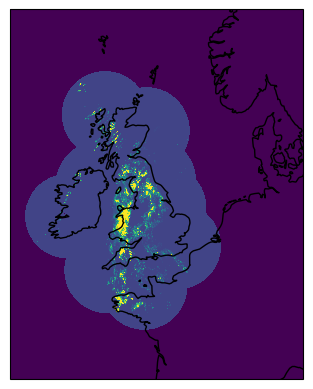

In [25]:
fig, ax = plt.subplots(1, subplot_kw={'projection': bng})
radar_1d['data'].plot(vmin=-1, vmax=4, ax=ax, add_colorbar=False, transform=bng)
ax.coastlines()

In [26]:
def shift_radar_img_to_haduk_grid(radar_1d, shift_in_m=500):
    dx = shift_in_m
    dy = shift_in_m

    new_x = np.round(radar_1d['x']) + dx
    new_y = np.round(radar_1d['y']) + dy
    
    radar_1d = radar_1d.rio.write_crs("epsg:27700")

    shifted_radar = radar_1d.interp(x=new_x, y=new_y)
    shifted_radar = shifted_radar.assign_coords(x=new_x)
    shifted_radar = shifted_radar.assign_coords(y=new_y)
    shifted_radar['data'] = shifted_radar['data'].fillna(-1.)
    return shifted_radar

# Load multiple radar timesteps into one dataset

In [27]:
month_files = fs.glob(f"{bucket_name}/radar/2024/12/*/*{search_term}*.h5") 

In [28]:
ZARR_OUTPUT_PATH = Path("output/radar.zarr")
BATCH_SIZE = 500

In [29]:
def batch(iterable, n):
    it = iter(iterable)
    while chunk := list(itertools.islice(it, n)):
        yield chunk

In [33]:
%%time
first_write = True

for batch_num, batch_files in enumerate(batch(month_files[:], BATCH_SIZE)):
    print(f"Batch {batch_num} — files {batch_num * BATCH_SIZE} to {batch_num * BATCH_SIZE + len(batch_files) - 1}")
    batch_results = []

    for ind, file in enumerate(batch_files):
        datatree = hdf5_loader(file)
        rounded_datetime = round_datetime_from_attrs(datatree['dataset1/what'], n_mins=15)
        one_radar = datatree['dataset1/data1'].to_dataset()
        one_radar['time'] = rounded_datetime
        one_radar = one_radar.set_coords('time')
        one_radar = set_coords_based_on_data_attrs(one_radar, data_attrs)
        one_radar = one_radar.sel(y=slice(1200000, -340000), x=slice(-320000, 848000))
        one_radar_shifted = shift_radar_img_to_haduk_grid(one_radar)
        batch_results.append(one_radar_shifted)

    batch_ds = xr.concat(batch_results, dim="time")
    del batch_results

    if first_write:
        batch_ds.to_zarr(ZARR_OUTPUT_PATH, mode="w", zarr_format=2)
        first_write = False
    else:
        batch_ds.to_zarr(ZARR_OUTPUT_PATH, append_dim="time", zarr_format=2)

    del batch_ds
    print(f"  Written batch {batch_num}")



Batch 0 — files 0 to 499
  Written batch 0
Batch 1 — files 500 to 999
  Written batch 1
Batch 2 — files 1000 to 1499
  Written batch 2
Batch 3 — files 1500 to 1999
  Written batch 3
Batch 4 — files 2000 to 2499
  Written batch 4
Batch 5 — files 2500 to 2644
  Written batch 5
CPU times: user 3min 18s, sys: 4min 44s, total: 8min 2s
Wall time: 11min 41s


In [34]:
combined_radar_ds = xr.open_zarr(ZARR_OUTPUT_PATH)

In [35]:
combined_radar_ds

<xarray.Dataset> Size: 38GB
Dimensions:      (time: 2645, y: 1540, x: 1168)
Coordinates:
  * time         (time) datetime64[ns] 21kB 2024-11-30 ... 2024-12-31T23:45:00
  * y            (y) float64 12kB 1.2e+06 1.2e+06 ... -3.375e+05 -3.385e+05
    spatial_ref  int64 8B ...
  * x            (x) float64 9kB -3.185e+05 -3.175e+05 ... 8.475e+05 8.485e+05
Data variables:
    data         (time, y, x) float64 38GB dask.array<chunksize=(32, 97, 146), meta=np.ndarray>

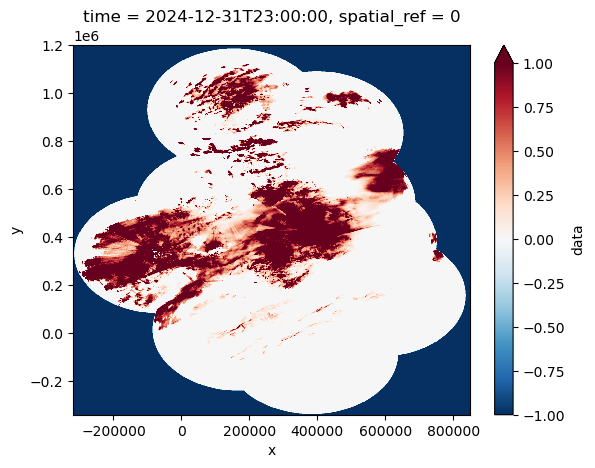

In [36]:
combined_radar_ds['data'].isel(time=-4).plot(vmin=-1)

In [37]:
# combined_radar_ds.to_netcdf('radar_aws_dec24.nc')

In [26]:
# %%time
# combined_radar_ls = []
# for ind, file in enumerate(month_files[:]):
#     datatree = hdf5_loader(file)
#     rounded_datetime = round_datetime_from_attrs(datatree['dataset1/what'], n_mins=15)
#     one_radar = datatree['dataset1/data1'].to_dataset()
#     one_radar['time'] = rounded_datetime
#     one_radar = one_radar.set_coords('time')
#     one_radar = set_coords_based_on_data_attrs(one_radar, data_attrs)
#     one_radar = one_radar.sel(y=slice(1200000, -340000), x=slice(-320000, 848000))
#     if ind % 100 == 0:
#         print(ind)
#     combined_radar_ls.append(one_radar)
        

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
CPU times: user 37 s, sys: 2.69 s, total: 39.7 s
Wall time: 4min 3s


In [27]:
# combined_radar = xr.concat(combined_radar_ls, dim='time')

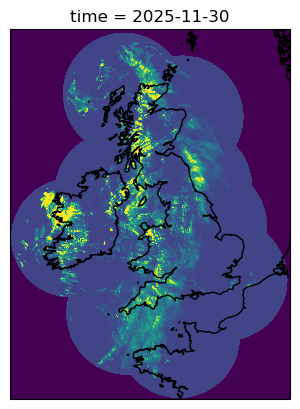

In [35]:
fig, ax = plt.subplots(1, subplot_kw={'projection': bng})
combined_radar_ds.isel(time=0)['data'].plot(vmin=-1, vmax=4, ax=ax, add_colorbar=False, transform=bng)
ax.coastlines()

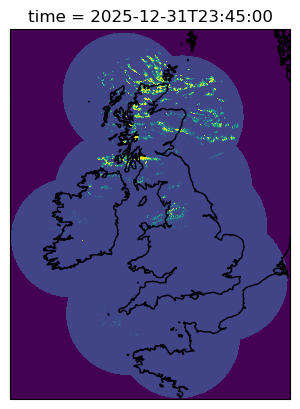

In [36]:
fig, ax = plt.subplots(1, subplot_kw={'projection': bng})
combined_radar_ds.isel(time=-1)['data'].plot(vmin=-1, vmax=4, ax=ax, add_colorbar=False, transform=bng)
ax.coastlines()

90 time steps == 60 MB 

# Shift for HadUK Grid?

In [38]:
dx = 500  # shift in meters (positive = right/east)
dy = 500  # shift in meters (positive = up/north)

new_x = np.round(radar_1d['x']) + dx
new_y = np.round(radar_1d['y']) + dy


In [39]:
radar_1d = radar_1d.rio.write_crs("epsg:27700")

In [40]:
radar_1d

<xarray.Dataset> Size: 15MB
Dimensions:      (y: 2175, x: 1725)
Coordinates:
  * x            (x) float64 14kB -4.04e+05 -4.03e+05 ... 1.319e+06 1.32e+06
  * y            (y) float64 17kB 1.549e+06 1.548e+06 ... -6.24e+05 -6.25e+05
    spatial_ref  int64 8B 0
Data variables:
    data         (y, x) float32 15MB ...
    time         datetime64[ns] 8B 2025-12-01T05:45:00

In [41]:
%%time
shifted_radar = radar_1d.interp(x=new_x, y=new_y)

shifted_radar = shifted_radar.assign_coords(x=new_x)
shifted_radar = shifted_radar.assign_coords(y=new_y)

CPU times: user 102 ms, sys: 332 ms, total: 434 ms
Wall time: 448 ms


In [42]:
## refill missing values
shifted_radar['data'] = shifted_radar['data'].fillna(-1.)

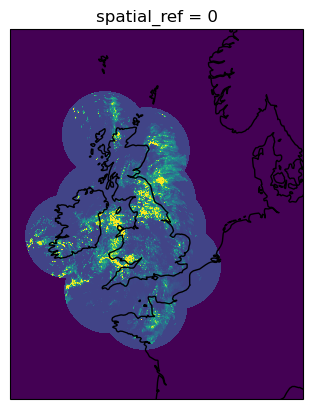

In [43]:
fig, ax = plt.subplots(1, subplot_kw={'projection': bng})
combined_radar['data'].plot(vmin=-1, vmax=4, ax=ax, add_colorbar=False, transform=bng)
ax.coastlines()

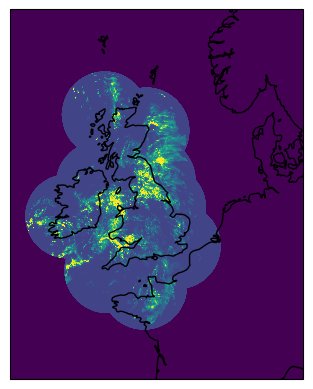

In [44]:
fig, ax = plt.subplots(1, subplot_kw={'projection': bng})
shifted_radar['data'].plot(vmin=-1, vmax=4, ax=ax, add_colorbar=False, transform=bng)
ax.coastlines()

In [45]:
shifted_radar

<xarray.Dataset> Size: 30MB
Dimensions:  (y: 2175, x: 1725)
Coordinates:
  * x        (x) float64 14kB -4.035e+05 -4.025e+05 ... 1.32e+06 1.32e+06
  * y        (y) float64 17kB 1.55e+06 1.548e+06 ... -6.235e+05 -6.245e+05
Data variables:
    data     (y, x) float64 30MB -1.0 -1.0 -1.0 -1.0 ... -1.0 -1.0 -1.0 -1.0
    time     datetime64[ns] 8B 2025-12-01T05:45:00

# subset to catchment

In [ ]:
chess_shp = gpd.read_file('FDRI_catchment_shps/Chess/Ricksmanworth/39088/NRFA_catchments.shp')
dolwen_shp = gpd.read_file('FDRI_catchment_shps/Upper Severn/Dolwen/54080/54080.shp')

In [ ]:
chess_shp.plot()

In [ ]:
chess_radar = shifted_radar.rio.clip(chess_shp.geometry.values, chess_shp.crs, drop=False, invert=False)
dolwen_radar = shifted_radar.rio.clip(dolwen_shp.geometry.values, dolwen_shp.crs, drop=False, invert=False)

In [ ]:
chess_radar['data'].plot()
plt.ylim(180000, 230000)
plt.xlim(470000, 520000) 

In [ ]:
dolwen_radar['data'].plot()
plt.ylim(200000, 300000)
plt.xlim(200000, 320000) 

In [ ]:
chess_radar = radar_1d.rio.clip(chess_shp.geometry.values, chess_shp.crs, drop=False, invert=False)
dolwen_radar = radar_1d.rio.clip(dolwen_shp.geometry.values, dolwen_shp.crs, drop=False, invert=False)

In [ ]:
chess_radar['data'].plot()
plt.ylim(180000, 230000)
plt.xlim(470000, 520000) 

In [ ]:
dolwen_radar['data'].plot()
plt.ylim(200000, 300000)
plt.xlim(200000, 320000) 

In [ ]:
def subset_hdf5_by_catchment():
    pass

# Save outputs
as NetCDF4